In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import patsy
import geopandas as gpd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import FuncFormatter
import statsmodels.api as sm
import sys
from datetime import datetime

In [24]:
RUN_BOTH_OUTPUT_MODES = True
base = "../outputs/tables/"
base_standardized = "../outputs/standardized_tables/"
MODEL_OUTPUTS_PATH = Path("../data/processed/model_outputs_by_region.csv")

y = "energy_burden_pct"  # change this to one of the outcomes in OUTCOMES_TO_RUN
OUTCOMES_TO_RUN = [
    "y_pv",
    "y_storage",
    "y_chargers",
    "y_wind_mw",
    "any_turbines",
    "y_level1_chargers",
    "y_level2_chargers",
    "y_dc_fast_chargers",
    "energy_burden_pct",
    "log_energy_gap_per_capita",
]


def prep_outcomes_per_capita(df, pop_col="total_population", min_pop=1000):
    """Create per-capita + log1p outcomes; filter tiny-pop ZIPs."""
    df = df.copy()
    df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce")
    der_zero_cols = [
        "PV_system_size_DC",
        "total_chargers",
        "level1_chargers",
        "level2_chargers",
        "dc_fast_chargers",
        "zev_count",
        "plant_capacity_mw",
        "storage_capacity_mw",
        "wind_capacity_mw",
        "wind_turbine_count",
    ]
    for col in der_zero_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df = df[df[pop_col].notna() & (df[pop_col] >= min_pop)].copy()

    pop = df[pop_col].replace(0, np.nan)
    df["level2_chargers_per_1k"] = df["level2_chargers"] * 1000 / pop
    df["y_level2_chargers"] = np.log1p(df["level2_chargers_per_1k"])

    df["level1_chargers_per_1k"] = df["level1_chargers"] * 1000 / pop
    df["y_level1_chargers"] = np.log1p(df["level1_chargers_per_1k"])

    df["dc_fast_chargers_per_1k"] = df["dc_fast_chargers"] * 1000 / pop
    df["y_dc_fast_chargers"] = np.log1p(df["dc_fast_chargers_per_1k"])

    df["chargers_per_1k"] = df["total_chargers"] * 1000 / pop
    df["y_chargers"] = np.log1p(df["chargers_per_1k"])

    df["pv_kw_per_1k"] = df["PV_system_size_DC"] * 1000 / pop
    df["y_pv"] = np.log1p(df["pv_kw_per_1k"])

    df["storage_mw_per_100k"] = df["storage_capacity_mw"] * 100000 / pop
    df["y_storage"] = np.log1p(df["storage_mw_per_100k"])

    df["wind_mw_per_100k"] = df["wind_capacity_mw"] * 100000 / pop
    df["y_wind_mw"] = np.log1p(df["wind_mw_per_100k"])

    # Binary wind outcome. wind_capacity_mw is ~97.5% zeros in the analysis sample, so
    # OLS on log1p of it is a rare-event indicator fit with a linear model. Presence /
    # absence is the honest specification and is what the archived any_turbines tables
    # used (a linear probability model with HC1 errors).
    df["any_turbines"] = (pd.to_numeric(df["wind_turbine_count"], errors="coerce").fillna(0) > 0).astype(float)

    df["plant_mw_per_100k"] = df["plant_capacity_mw"] * 100000 / pop
    df["wind_mw_per_100k_ctrl"] = df["wind_capacity_mw"] * 100000 / pop
    df["turbines_per_100k"] = df["wind_turbine_count"] * 100000 / pop

    df["log_median_household_income"] = np.log(df["median_household_income"].where(df["median_household_income"] > 0))
    df["log_median_housing_value"] = np.log(df["median_housing_value"].where(df["median_housing_value"] > 0))
    df["combined_nonwhite_share"] = df[["pct_black", "pct_hispanic", "pct_asian"]].sum(axis=1, min_count=1)

    df["energy_burden_pct"] = pd.to_numeric(df["energy_burden_pct"], errors="coerce")
    df["energy_gap_per_capita"] = df["energy_affordability_gap"] / pop
    df["log_energy_gap_per_capita"] = np.log1p(df["energy_gap_per_capita"])

    return df


def center_cols(df, cols):
    """Mean-center columns for interaction models."""
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c + "_c"] = df[c] - df[c].mean()
    return df


def run_ols(formula, df, cluster_col=None):
    """Run OLS with HC1 SEs by default; optional clustered SEs."""
    m = smf.ols(formula=formula, data=df)

    if cluster_col is None:
        return m.fit(cov_type="HC1")
    res = m.fit()
    used_idx = res.model.data.row_labels
    groups = df.loc[used_idx, cluster_col].copy()
    groups = groups.fillna("MISSING").astype(str)
    return m.fit(cov_type="cluster", cov_kwds={"groups": groups})


def vif_from_formula(formula, df, exclude_prefixes=("C(",), drop_intercept=True):
    y_mat, X = patsy.dmatrices(formula, df, return_type="dataframe")

    if drop_intercept and "Intercept" in X.columns:
        X = X.drop(columns=["Intercept"])

    if exclude_prefixes:
        keep = []
        for col in X.columns:
            if not any(col.startswith(pref) for pref in exclude_prefixes):
                keep.append(col)
        X = X[keep]

    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False)

    return vif


In [25]:
def clean_region_id(value):
    """
    Keeps ZCTAs/ZIPs as 5-character strings.
    Example: 9001 -> '09001'
    """
    if pd.isna(value):
        return None
    return str(value).split(".")[0].zfill(5)


def model_output_rows_from_result(
    df_used_for_model,
    result,
    outcome,
    model_version,
    assumptions,
    region_id_col="zip_code",
):
    """
    Convert one fitted statsmodels result into wide-format rows
    for the model_outputs SQL table.

    Each row corresponds to:

        one region + one outcome + one model version

    Output columns:
    - region_id
    - outcome_name
    - model_version
    - actual_value
    - predicted_value
    - residual_value
    - residual_percentile
    - priority_flag
    - assumptions
    - generated_at
    """

    required_columns = {region_id_col, outcome}
    missing_columns = required_columns - set(df_used_for_model.columns)

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    generated_at = datetime.utcnow().isoformat()

    # Statsmodels may drop rows with missing values.
    # This retrieves the exact rows used in the fitted model.
    used_idx = result.model.data.row_labels

    outputs_df = df_used_for_model.loc[used_idx, [region_id_col, outcome]].copy()

    outputs_df[region_id_col] = outputs_df[region_id_col].apply(clean_region_id)
    outputs_df = outputs_df.dropna(subset=[region_id_col])

    outputs_df["actual_value"] = outputs_df[outcome]
    outputs_df["predicted_value"] = result.fittedvalues
    outputs_df["residual_value"] = result.resid

    # Percentile rank of residuals.
    # Low residual percentile = actual is lower than predicted.
    # High residual percentile = actual is higher than predicted.
    outputs_df["residual_percentile"] = outputs_df["residual_value"].rank(pct=True)

    der_outcomes = {
        "y_pv",
        "y_storage",
        "y_chargers",
        "y_level1_chargers",
        "y_level2_chargers",
        "y_dc_fast_chargers",
        "y_wind_mw",
    }

    burden_outcomes = {
        "energy_burden_pct",
        "energy_affordability_index",
        "log_energy_gap_per_capita",
    }

    if outcome in der_outcomes:
        # For DER adoption, low residual = lower adoption than expected.
        cutoff = outputs_df["residual_value"].quantile(0.25)
        outputs_df["priority_flag"] = (
            outputs_df["residual_value"] <= cutoff
        ).astype(int)

    elif outcome in burden_outcomes:
        # For burden outcomes, high residual = higher burden than expected.
        cutoff = outputs_df["residual_value"].quantile(0.75)
        outputs_df["priority_flag"] = (
            outputs_df["residual_value"] >= cutoff
        ).astype(int)

    else:
        # Generic fallback: flag unusually large absolute residuals.
        cutoff = outputs_df["residual_value"].abs().quantile(0.75)
        outputs_df["priority_flag"] = (
            outputs_df["residual_value"].abs() >= cutoff
        ).astype(int)

    rows = []

    for _, row in outputs_df.iterrows():
        rows.append(
            {
                "region_id": row[region_id_col],
                "outcome_name": outcome,
                "model_version": model_version,
                "actual_value": float(row["actual_value"]),
                "predicted_value": float(row["predicted_value"]),
                "residual_value": float(row["residual_value"]),
                "residual_percentile": float(row["residual_percentile"]),
                "priority_flag": int(row["priority_flag"]),
                "assumptions": assumptions,
                "generated_at": generated_at,
            }
        )

    return rows

In [26]:
#### THIS IS JUST FOR CALCULATING DIFFERENT FEATURES
#### ONLY MODIFY TO ADD FEATURES
df = pd.read_csv("../data/processed/combined_der_dataset_w_controls_predictors.csv")
df.drop(columns=['Unnamed: 0'], inplace=True, errors="ignore")
df.rename(columns={"ghi_mean_kwh_m2_day_2024":"ghi_mean_kwh_m2_day_2023",
"wind_ws10m_mean_2024": "wind_ws10m_mean_2023",
    "wind_ws50m_mean_2024": "wind_ws50m_mean_2023"}, inplace=True)
# numeric coercion for key vars (safe)
for c in [
    "median_household_income", "poverty_rate", "pct_bachelors_plus",
    "pct_black", "pct_hispanic", "pct_asian", "median_housing_value",
    "pct_single_family_units", "pct_multifamily_units", "pct_mobile_home_units",
    "cdd65_2023", "hdd65_2023", "t2m_mean_c_2023",
    "ghi_mean_kwh_m2_day_2023", "wind_ws10m_mean_2023", "wind_ws50m_mean_2023",
    "total_population", "lat", "lon", "log_kwh",
    "plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw", "wind_turbine_count",
    "PV_system_size_DC", "total_chargers", "level1_chargers", "level2_chargers", "dc_fast_chargers",
]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["utility_type"] = df["utility_type"].fillna("POU")
df = prep_outcomes_per_capita(df, min_pop=1000)

core_needed = ["median_household_income", "pct_black", "pct_hispanic", "pct_asian"]
df = df.dropna(subset=[c for c in core_needed if c in df.columns]).copy()

<Axes: >

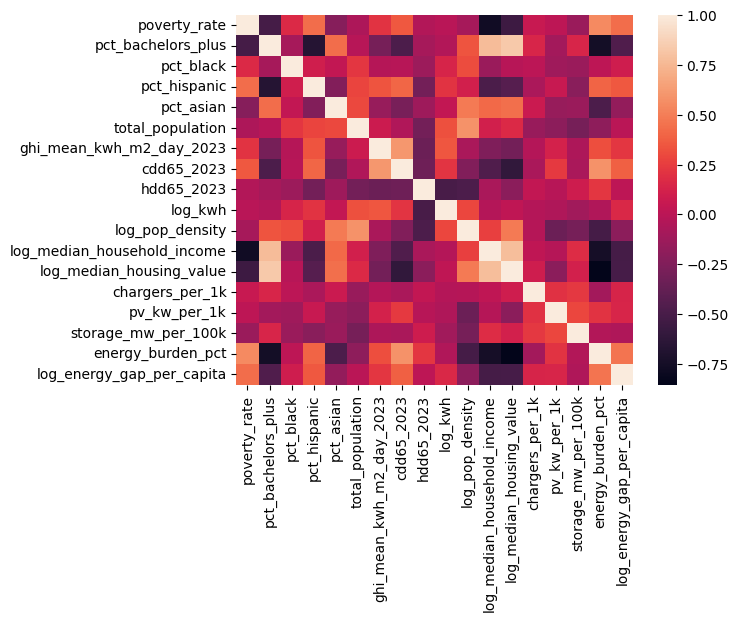

In [27]:
corr = df[[
       'poverty_rate',
       'pct_bachelors_plus', 'pct_black', 'pct_hispanic', 'pct_asian',
       'total_population', 'ghi_mean_kwh_m2_day_2023',
       'cdd65_2023', 'hdd65_2023',
       'log_kwh',
       'log_pop_density',
       'log_median_household_income', 'log_median_housing_value',
       'pct_single_family_units', 'pct_multifamily_units', 'pct_mobile_home_units',
       'chargers_per_1k', #'y_chargers',
       'pv_kw_per_1k', #'y_pv',
       'storage_mw_per_100k', #'y_storage', 'y_wind_mw',
       "energy_burden_pct",
       "log_energy_gap_per_capita"
       ]].corr()

sns.heatmap(corr)

In [28]:

sys.path.append(str(Path("../scripts").resolve()))
from paper_figure_utils import GRID, MUTED, PAPER_BG, TERM_COLORS, apply_paper_style

OUTPUT_TABLE_DIRS = {
    False: Path("../outputs/tables"),
    True: Path("../outputs/standardized_tables"),
}
GENERATED_FIG_DIR = Path("../outputs/figures/generated")
RUN_MAPS = False
SUPPORTED_NOTEBOOK_OUTCOMES = {"y_pv", "y_storage", "y_chargers", "y_wind_mw", "any_turbines", "y_level1_chargers", "y_level2_chargers", "y_dc_fast_chargers", "energy_burden_pct", "log_energy_gap_per_capita"}
LOWESS_SEED = 42
LOWESS_FRAC = 0.35
LOWESS_BOOTSTRAPS = 300
LOWESS_GRID_SIZE = 200
LOWESS_CI = 95

income = "log_median_household_income"
race = ["pct_black", "pct_hispanic", "pct_asian"]
race_summary = "combined_nonwhite_share"
controls_common = ["poverty_rate"]
controls_3A = ["cdd65_2023", "hdd65_2023"]
controls_3B = ["t2m_mean_c_2023"]
controls_3C = ["ghi_mean_kwh_m2_day_2023"]
controls_3D = ["wind_ws50m_mean_2023"]
ses_bach = ["pct_bachelors_plus"]
ses_house = ["log_median_housing_value"]
# The three housing-structure shares sum to 1 by construction, so entering all three
# alongside an intercept is a compositional dummy-variable trap: VIFs came out at
# 1258 / 1077 / 199 and the individual coefficients were not interpretable. Single-
# family is the omitted reference, so these read as "relative to single-family units".
HOUSING_STRUCTURE_REFERENCE = "pct_single_family_units"
housing_structure = ["pct_multifamily_units", "pct_mobile_home_units"]
# B25003 tenure. Owner share only - owner and renter sum to 1, so renters are the
# omitted reference. Kept as its own control set so Model 2D can show what tenure adds
# beyond building type: single-family share explains only ~62% of tenure variation.
tenure = ["owner_occupied_rate"]
utility_fe = "C(utility)"
cluster_utility = "utility"
# county_geoid round-trips through CSV as a float (NaN forces float64), so a bare
# astype(str) yields "6037.0" and turns missing counties back into a "nan" level that
# behaves like a real county in C(county_geoid) and in county-clustered SEs. Restore
# the zero-padded FIPS string and keep missing as genuine NA.
def _fips5(value):
    """county_geoid round-trips through CSV as a float (NaN forces float64), so a bare
    astype(str) yields "6037.0" and turns missing counties into a "nan" level that acts
    like a real county in C(county_geoid) and in county-clustered SEs."""
    if pd.isna(value):
        return pd.NA
    return str(int(float(value))).zfill(5)


df["county_geoid"] = df["county_geoid"].map(_fips5).astype("string")
county_fe = "C(county_geoid)"
latlon = ["lat", "lon"]
demand_proxy = "log_kwh"
energy_burden_features = ["energy_burden_pct", "log_energy_gap_per_capita"]

term_labels = {
    "cdd65_2023": "Cooling degree days",
    "hdd65_2023": "Heating degree days",
    "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
    "wind_ws10m_mean_2023": "Wind speed (10m)",
    "wind_ws50m_mean_2023": "Wind speed (50m)",
    "poverty_rate": "Poverty rate",
    "pct_bachelors_plus": "% Bachelor's+",
    "pct_black": "% Black",
    "pct_hispanic": "% Hispanic",
    "pct_asian": "% Asian",
    "pct_single_family_units": "% single-family units",
    "pct_multifamily_units": "% multifamily units",
    "pct_mobile_home_units": "% mobile-home units",
    "combined_nonwhite_share": "Combined non-white share",
    "log_median_household_income": "Log median household income",
    "log_median_housing_value": "Log median housing value",
    "log_pop_density": "Log population density",
    "log_kwh": "Log annual electricity demand",
    "energy_burden_pct": "Energy burden",
    "energy_affordability_index": "Energy affordability index",
    "log_energy_gap_per_capita": "Log energy affordability gap per capita",
    "y_pv": "Solar PV adoption",
    "y_chargers": "EV charger availability",
    "y_level1_chargers": "Level 1 charger availability",
    "y_level2_chargers": "Level 2 charger availability",
    "y_dc_fast_chargers": "DC fast charger availability",
    "y_storage": "Storage deployment",
    "y_wind_mw": "Wind capacity",
    "any_turbines": "Any turbines (presence)",
    "owner_occupied_rate": "% owner-occupied",
}

analysis_df_raw = df.copy()


In [29]:
def build_formula(outcome, climate_controls, extra_terms=None, fe_terms=None,
                  keepincome=True, demand_proxy_term=None, controls_common_terms=None):
    rhs = []
    if keepincome:
        rhs.append(income)
    rhs += race
    rhs += list(controls_common_terms or controls_common)
    if demand_proxy_term is not None:
        rhs.append(demand_proxy_term)
    rhs += list(climate_controls or [])
    if extra_terms:
        rhs += list(extra_terms)
    if fe_terms:
        rhs += list(fe_terms)
    seen = set()
    rhs = [x for x in rhs if not (x in seen or seen.add(x))]
    return f"{outcome} ~ " + " + ".join(rhs)


def controls_for_outcome(outcome):
    if outcome == "y_pv":
        return controls_3C
    if outcome == "y_storage":
        return controls_3A
    if outcome in {"y_chargers", "y_level1_chargers", "y_level2_chargers", "y_dc_fast_chargers"}:
        return controls_3A
    if outcome in {"y_wind_mw", "any_turbines"}:
        return controls_3D
    if outcome in energy_burden_features:
        return controls_3A + controls_3C
    return []


def standardize_model_frame(source_df, outcome):
    df_model = source_df.copy()
    candidate_standardized_predictors = [
        "log_median_household_income",
        "log_median_housing_value",
        "log_pop_density",
        "poverty_rate",
        "pct_bachelors_plus",
        "pct_black",
        "pct_hispanic",
        "pct_asian",
        "combined_nonwhite_share",
        "pct_single_family_units",
        "pct_multifamily_units",
        "pct_mobile_home_units",
        "owner_occupied_rate",
        "cdd65_2023",
        "hdd65_2023",
        "t2m_mean_c_2023",
        "ghi_mean_kwh_m2_day_2023",
        "wind_ws10m_mean_2023",
        "wind_ws50m_mean_2023",
        "lat",
        "lon",
        "log_kwh",
        "plant_capacity_mw",
        "storage_capacity_mw",
        "wind_capacity_mw",
        "wind_turbine_count",
        "PV_system_size_DC",
        "plant_mw_per_100k",
        "storage_mw_per_100k",
        "wind_mw_per_100k_ctrl",
        "turbines_per_100k",
        "energy_burden_pct",
        "energy_affordability_index",
        "log_energy_gap_per_capita",
        "y_pv",
        "y_storage",
        "y_chargers",
        "y_wind_mw",
        "y_level1_chargers",
        "y_level2_chargers",
        "y_dc_fast_chargers",
    ]
    cols_to_standardize = [
        c for c in candidate_standardized_predictors
        if c in df_model.columns and c != outcome and df_model[c].nunique(dropna=True) > 1
    ]
    if cols_to_standardize:
        df_model[cols_to_standardize] = StandardScaler().fit_transform(df_model[cols_to_standardize])
    return df_model


def export_result_table(res, title, table_dir):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(res.summary().tables[0])
    print(res.summary().tables[1])
    table_dir.mkdir(parents=True, exist_ok=True)
    res.summary2().tables[1].to_csv(table_dir / f"{title}.csv")


def export_vif_table(formula, df_model, title, table_dir):
    vif = vif_from_formula(formula, df_model)
    print(vif.head(30))
    vif.to_csv(table_dir / f"{title} VIF.csv", index=False)
    return vif


def run_outcome_suite(outcome, source_df, standardized_flag):
    table_dir = OUTPUT_TABLE_DIRS[standardized_flag]
    mode_label = "standardized" if standardized_flag else "raw"
    controls_cur = controls_for_outcome(outcome)
    df_model = standardize_model_frame(source_df, outcome) if standardized_flag else source_df.copy()
    model_outputs_rows = []

    def store_result(
        label,
        res,
        df_used_for_model=None,
        save_model_outputs=True,
        assumptions=None,
    ):
        export_result_table(res, f"{outcome} | {label}", table_dir)

        if save_model_outputs:
            if df_used_for_model is None:
                df_used_for_model = df_model

            model_version = f"{outcome} | {label} | {mode_label}"

            if assumptions is None:
                assumptions_text = f"{mode_label} OLS model for {outcome}: {label}."
            else:
                assumptions_text = assumptions

            model_outputs_rows.extend(
                model_output_rows_from_result(
                    df_used_for_model=df_used_for_model,
                    result=res,
                    outcome=outcome,
                    model_version=model_version,
                    assumptions=assumptions_text,
                    region_id_col="zip_code",
                )
            )
        return res

    f1 = build_formula(outcome, climate_controls=controls_cur, controls_common_terms=["poverty_rate"])
    res1 = store_result("Model 1 baseline (climate controls)", run_ols(f1, df_model))
    export_vif_table(f1, df_model, f"{outcome} | Model 1 baseline (climate controls)", table_dir)

    f2a = build_formula(outcome, climate_controls=controls_cur, extra_terms=ses_bach, keepincome=True, controls_common_terms=["poverty_rate"])
    res2a = store_result("Model 2 (add bachelors)", run_ols(f2a, df_model))
    export_vif_table(f2a, df_model, f"{outcome} | Model 2 (add bachelors)", table_dir)

    f2b = build_formula(outcome, climate_controls=controls_cur, extra_terms=ses_house, keepincome=True, controls_common_terms=["poverty_rate"])
    res2b = store_result("Model 2 (add housing value)", run_ols(f2b, df_model))
    export_vif_table(f2b, df_model, f"{outcome} | Model 2 (add housing value)", table_dir)

    available_housing_structure = [
        c for c in housing_structure
        if c in df_model.columns and df_model[c].nunique(dropna=True) > 1
    ]
    f2c = build_formula(outcome, climate_controls=controls_cur, extra_terms=available_housing_structure, keepincome=True, controls_common_terms=["poverty_rate"])
    res2c = store_result("Model 2C (add housing structure)", run_ols(f2c, df_model))
    export_vif_table(f2c, df_model, f"{outcome} | Model 2C (add housing structure)", table_dir)

    available_tenure = [
        c for c in tenure
        if c in df_model.columns and df_model[c].nunique(dropna=True) > 1
    ]
    f2d = build_formula(
        outcome, climate_controls=controls_cur,
        extra_terms=available_housing_structure + available_tenure,
        keepincome=True, controls_common_terms=["poverty_rate"],
    )
    res2d = store_result("Model 2D (add housing structure and tenure)", run_ols(f2d, df_model))
    export_vif_table(f2d, df_model, f"{outcome} | Model 2D (add housing structure and tenure)", table_dir)

    f3a = build_formula(outcome, climate_controls=controls_3A)
    res3a = store_result("Model 3A (HDD + CDD)", run_ols(f3a, df_model))
    export_vif_table(f3a, df_model, f"{outcome} | Model 3A (HDD + CDD)", table_dir)

    f3b = build_formula(outcome, climate_controls=controls_3B)
    res3b = store_result("Model 3B (temp only)", run_ols(f3b, df_model))
    export_vif_table(f3b, df_model, f"{outcome} | Model 3B (temp only)", table_dir)

    f3c = build_formula(outcome, climate_controls=controls_3C)
    res3c = store_result("Model 3C (GHI only)", run_ols(f3c, df_model))
    export_vif_table(f3c, df_model, f"{outcome} | Model 3C (GHI only)", table_dir)

    df_int = center_cols(df_model, [income] + race)
    f4 = (
        f"{outcome} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
        + (" + " + " + ".join(["poverty_rate"] + list(controls_cur)) if controls_cur else " + poverty_rate")
        + " + log_median_household_income_c:pct_black_c"
        + " + log_median_household_income_c:pct_hispanic_c"
        + " + log_median_household_income_c:pct_asian_c"
    )
    res4 = store_result("Model 4 interactions (centered)", run_ols(f4, df_int))
    export_vif_table(f4, df_int, f"{outcome} | Model 4 interactions (centered)", table_dir)

    # Model 4R is the RESTRICTED counterpart to Model 4: it drops poverty_rate, which
    # overlaps heavily with log median household income, and asks whether the
    # income-by-race interactions survive without that collinear control. Previously
    # 4R spelled the same control set as Model 4 via controls_common, so the two
    # models were byte-identical and the ladder carried a duplicated rung.
    f4r = (
        f"{outcome} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
        + (" + " + " + ".join(list(controls_cur)) if controls_cur else "")
        + " + log_median_household_income_c:pct_black_c"
        + " + log_median_household_income_c:pct_hispanic_c"
        + " + log_median_household_income_c:pct_asian_c"
    )
    res4r = store_result("Model 4R interactions (centered, no poverty control)", run_ols(f4r, df_int))
    export_vif_table(f4r, df_int, f"{outcome} | Model 4R interactions (centered, no poverty control)", table_dir)

    f5 = build_formula(outcome, climate_controls=controls_cur, fe_terms=[utility_fe])
    res5 = store_result("Model 5 utility FE", run_ols(f5, df_model))
    export_vif_table(f5, df_model, f"{outcome} | Model 5 utility FE", table_dir)
    res5c = store_result("Model 5C clustered SEs by county", run_ols(f5, df_model, cluster_col="county_geoid"))

    f6a = build_formula(outcome, climate_controls=[], extra_terms=latlon)
    res6a = store_result("Model 6A lat and lon", run_ols(f6a, df_model))
    export_vif_table(f6a, df_model, f"{outcome} | Model 6A lat and lon", table_dir)

    f6b = build_formula(outcome, climate_controls=[], extra_terms=[county_fe])
    res6b = store_result("Model 6B county fe", run_ols(f6b, df_model))
    export_vif_table(f6b, df_model, f"{outcome} | Model 6B county fe", table_dir)
    res6_cluster = store_result("No County FE + clustered SEs (county)", run_ols(f1, df_model, cluster_col="county_geoid"))

    charger_exclusions = [
        "total_chargers",
        "level1_chargers",
        "level2_chargers",
        "dc_fast_chargers",
        "chargers_per_1k",
        "level1_chargers_per_1k",
        "level2_chargers_per_1k",
        "dc_fast_chargers_per_1k",
        "y_chargers",
        "y_level1_chargers",
        "y_level2_chargers",
        "y_dc_fast_chargers",
    ]
    exclude_for_y = {
        "y_chargers": charger_exclusions,
        "y_level1_chargers": charger_exclusions,
        "y_level2_chargers": charger_exclusions,
        "y_dc_fast_chargers": charger_exclusions,
        "y_pv": ["PV_system_size_DC", "pv_kw_per_1k", "y_pv"],
        "y_storage": ["storage_capacity_mw", "storage_mw_per_100k"],
        "y_wind_mw": ["wind_capacity_mw", "wind_mw_per_100k"],
        "any_turbines": ["wind_capacity_mw", "wind_mw_per_100k", "wind_turbine_count", "wind_mw_per_100k_ctrl", "turbines_per_100k", "any_turbines"],
    }
    infra_candidates = ["plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw", "wind_turbine_count", "PV_system_size_DC"]
    infra = [c for c in infra_candidates if c in df_model.columns and c not in exclude_for_y.get(outcome, [])]
    f7 = build_formula(outcome, climate_controls=controls_cur, extra_terms=infra)
    res7 = store_result("Model 7 (infrastructure controls, outcome-safe)", run_ols(f7, df_model))
    export_vif_table(f7, df_model, f"{outcome} | Model 7 (infrastructure controls, outcome-safe)", table_dir)

    infra_pc = [c for c in ["plant_mw_per_100k", "storage_mw_per_100k", "wind_mw_per_100k_ctrl", "turbines_per_100k"] if c in df_model.columns]
    infra_pc = [c for c in infra_pc if c not in exclude_for_y.get(outcome, [])]
    f7pc = build_formula(outcome, climate_controls=controls_cur, extra_terms=infra_pc)
    res7pc = store_result("Model 7 (per-capita infrastructure controls)", run_ols(f7pc, df_model))
    export_vif_table(f7pc, df_model, f"{outcome} | Model 7 (per-capita infrastructure controls)", table_dir)

    f8 = build_formula(outcome, climate_controls=controls_cur, extra_terms=[demand_proxy])
    res8 = store_result("Model 8 add demand proxy", run_ols(f8, df_model))
    export_vif_table(f8, df_model, f"{outcome} | Model 8 add demand proxy", table_dir)

    if outcome in energy_burden_features:
        # Model 9A (predicting burden): flips the direction of the analysis and asks
        # whether DER access predicts affordability outcomes. Restored from an earlier
        # notebook version - the figure that consumes it (energy_burden_der_m9.png) had
        # been drawing on an orphaned table no code produced.
        #
        # log_median_household_income is deliberately EXCLUDED. Energy burden is
        # conventionally energy cost divided by household income, so income sits in the
        # outcome's denominator; regressing burden on income is substantially mechanical
        # (income alone explains R^2 = 0.556). See AUDIT.md. poverty_rate is dropped for
        # the same reason. Terms match the archived specification exactly.
        m9_burden_terms = ["y_pv", "y_storage", "y_chargers"]
        f9b = f"{outcome} ~ " + " + ".join(
            race + [demand_proxy] + list(controls_cur) + m9_burden_terms
        )
        res9b = store_result("Model 9A (predicting burden)", run_ols(f9b, df_model))
        export_vif_table(f9b, df_model, f"{outcome} | Model 9A (predicting burden)", table_dir)

    if outcome == "y_storage":
        model9_terms = ["pct_bachelors_plus", "plant_mw_per_100k", "wind_mw_per_100k_ctrl", "y_pv"]
        f9 = build_formula(
            outcome,
            climate_controls=controls_cur,
            extra_terms=model9_terms,
            keepincome=True,
            demand_proxy_term=demand_proxy,
            controls_common_terms=["poverty_rate"],
        )
        res9 = store_result("Model 9 + pv control (most controlled)", run_ols(f9, df_model))
        export_vif_table(f9, df_model, f"{outcome} | Model 9 + pv control (most controlled)", table_dir)

    # Plot generation lives in plotting_outcomes.ipynb so regression reruns only export model outputs.

    print(f"Completed {outcome} ({mode_label})")
    return {
        "outcome": outcome,
        "mode": mode_label,
        "model_outputs_rows": model_outputs_rows,
    }


In [30]:
all_model_outputs_rows = []

for y in OUTCOMES_TO_RUN:
    result_dict = run_outcome_suite(y, analysis_df_raw, False)
    model_outputs_rows = result_dict.pop("model_outputs_rows", [])
    all_model_outputs_rows.extend(model_outputs_rows)

if RUN_BOTH_OUTPUT_MODES:
    for y in OUTCOMES_TO_RUN:
        run_outcome_suite(y, analysis_df_raw, True)

model_outputs_df = pd.DataFrame(all_model_outputs_rows)
MODEL_OUTPUTS_PATH.parent.mkdir(parents=True, exist_ok=True)
model_outputs_df.to_csv(MODEL_OUTPUTS_PATH, index=False)

print(f"Saved model outputs to {MODEL_OUTPUTS_PATH}")
display(model_outputs_df.head())
display(model_outputs_df["model_version"].value_counts())


y_pv | Model 1 baseline (climate controls)
                            OLS Regression Results                            
Dep. Variable:                   y_pv   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     41.45
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.27e-46
Time:                        22:54:03   Log-Likelihood:                -376.99
No. Observations:                1386   AIC:                             768.0
Df Residuals:                    1379   BIC:                             804.6
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

,region_id,outcome_name,model_version,actual_value,predicted_value,residual_value,residual_percentile,priority_flag,assumptions,generated_at
0,90001,y_pv,y_pv | Model 1 baseline (climate controls) | raw,0.060533,0.346634,-0.286101,0.176046,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-06-08T05:54:03.169721
1,90002,y_pv,y_pv | Model 1 baseline (climate controls) | raw,0.038223,0.266757,-0.228534,0.239538,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-06-08T05:54:03.169721
2,90003,y_pv,y_pv | Model 1 baseline (climate controls) | raw,0.014076,0.258233,-0.244157,0.219336,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-06-08T05:54:03.169721
3,90004,y_pv,y_pv | Model 1 baseline (climate controls) | raw,0.027093,0.298884,-0.271791,0.191198,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-06-08T05:54:03.169721
4,90005,y_pv,y_pv | Model 1 baseline (climate controls) | raw,0.023076,0.224681,-0.201605,0.272727,0,raw OLS model for y_pv: Model 1 baseline (clim...,2026-06-08T05:54:03.169721


model_version
y_pv | Model 1 baseline (climate controls) | raw                             1386
y_level2_chargers | Model 1 baseline (climate controls) | raw                1386
y_level1_chargers | Model 7 (infrastructure controls, outcome-safe) | raw    1386
y_level1_chargers | No County FE + clustered SEs (county) | raw              1386
y_level1_chargers | Model 6B county fe | raw                                 1386
                                                                             ... 
y_storage | Model 8 add demand proxy | raw                                   1218
y_storage | Model 9 + pv control (most controlled) | raw                     1218
y_wind_mw | Model 8 add demand proxy | raw                                   1218
energy_burden_pct | Model 8 add demand proxy | raw                           1207
log_energy_gap_per_capita | Model 8 add demand proxy | raw                   1207
Name: count, Length: 145, dtype: int64

In [33]:
model_outputs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196932 entries, 0 to 196931
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   region_id            196932 non-null  object 
 1   outcome_name         196932 non-null  object 
 2   model_version        196932 non-null  object 
 3   actual_value         196932 non-null  float64
 4   predicted_value      196932 non-null  float64
 5   residual_value       196932 non-null  float64
 6   residual_percentile  196932 non-null  float64
 7   priority_flag        196932 non-null  int64  
 8   assumptions          196932 non-null  object 
 9   generated_at         196932 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 15.0+ MB


In [32]:
zip_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_zcta520/tl_2023_us_zcta520.shp")
county_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_county/tl_2023_us_county.shp")
ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
ca_counties = ca_counties.to_crs(zip_gdf.crs)
ca_outline = ca_counties.dissolve()

ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
print(zip_gdf.columns)
zip_gdf["zip_code"] = zip_gdf["ZCTA5CE20"].astype(str).str.zfill(5)
# or
# zip_gdf["zip_code"] = zip_gdf["GEOID20"].astype(str).str.zfill(5)
df["zip_code"] = df["zip_code"].astype(str).str.zfill(5)
ca_zips = set(df["zip_code"].dropna().unique())
zip_gdf = zip_gdf[zip_gdf["zip_code"].isin(ca_zips)].copy()
def make_paper_spatial_figure(
    df,
    zip_gdf,
    res,
    outcome_col,
    id_col="zip_code",
    observed_title=None,
    residual_title=None,
    residual_col="std_residual",
    observed_cmap="viridis",
    residual_cmap="coolwarm",
    figsize=(16, 7),
    hotspot_threshold=None,
    save_path=None,
    ca_outline_gdf=None
):
    """
    Create a paper-style two-panel spatial figure:
    left = observed outcome by ZIP
    right = model residuals by ZIP

    Parameters
    ----------
    df : pd.DataFrame
        Original modeling dataframe.
    zip_gdf : gpd.GeoDataFrame
        ZIP geometry dataframe.
    res : statsmodels results object
        Fitted regression results object.
    outcome_col : str
        Outcome column in df to map, e.g. 'y_pv' or 'y_storage'.
    id_col : str, default 'zip_code'
        Merge key present in both df and zip_gdf.
    observed_title : str or None
        Title for the observed map.
    residual_title : str or None
        Title for the residual map.
    residual_col : str, default 'std_residual'
        Residual column to plot; one of {'residual', 'std_residual'}.
    observed_cmap : str
        Colormap for observed values.
    residual_cmap : str
        Colormap for residuals.
    figsize : tuple
        Figure size.
    hotspot_threshold : float or None
        If provided, outline ZIPs with abs(residual) >= threshold on the residual panel.
        Best used with standardized residuals.
    save_path : str or None
        If provided, save figure to this path.

    Returns
    -------
    merged : gpd.GeoDataFrame
        GeoDataFrame used for plotting.
    fig, axes
        Matplotlib figure and axes.
    """
    # Copy and standardize merge keys
    df2 = df.copy()
    gdf2 = zip_gdf.copy()

    df2[id_col] = df2[id_col].astype(str).str.zfill(5)
    gdf2[id_col] = gdf2[id_col].astype(str).str.zfill(5)

    # Get rows used in model
    used_idx = res.model.data.row_labels
    diag = df2.loc[used_idx, [id_col]].copy()
    diag["fitted"] = res.fittedvalues
    diag["residual"] = res.resid
    diag["std_residual"] = (res.resid - np.mean(res.resid)) / np.std(res.resid)

    # Keep one observed value per ZIP
    observed = df2[[id_col, outcome_col]].drop_duplicates(subset=[id_col]).copy()

    # Merge onto geometry
    merged = gdf2.merge(observed, on=id_col, how="left")
    merged = merged.merge(diag, on=id_col, how="left")

    # California outer outline only
    ca_outline = merged.dissolve()

    # Default titles
    if observed_title is None:
        observed_title = f"{outcome_col} by ZIP"
    if residual_title is None:
        residual_title = f"{outcome_col} model standardized residuals" if residual_col == "std_residual" else f"{outcome_col} model residuals"

    # Residual color scale centered at zero
    vmax = np.nanmax(np.abs(merged[residual_col]))
    if np.isnan(vmax) or vmax == 0:
        vmax = 1.0

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: observed outcome
    merged.plot(
        column=outcome_col,
        cmap=observed_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        ax=axes[0],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[0],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[0],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[0].set_title(observed_title)
    axes[0].axis("off")

    # Right: residuals
    merged.plot(
        column=residual_col,
        cmap=residual_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        vmin=-vmax,
        vmax=vmax,
        ax=axes[1],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[1],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )

    # Optional hotspot outlines
    if hotspot_threshold is not None:
        hotspots = merged[merged[residual_col].abs() >= hotspot_threshold]
        if len(hotspots) > 0:
            hotspots.boundary.plot(ax0=axes[1], linewidth=0.8, color="black")
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[1],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[1].set_title(residual_title)
    axes[1].axis("off")
    plt.tight_layout()

    if save_path is not None:
        fig.patch.set_alpha(0)
        for ax in axes:
            ax.patch.set_alpha(0)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()
    return merged, fig, axes

NameError: name 'gpd' is not defined